Author: Daniel Lillard

Date: 2026.02.20

Desc: We look at two things here, calling from the API of Alpha Advantage to grab quarterly reports, and using those to generate the ten financial ratios used in the paper: https://www.sciencedirect.com/science/article/pii/S1057521923001734/

They are as listed:

- Total liabilities/net worth
- working capital/sales
- Pretax net nonop inc/Sales
- (Net Inc - Divid)/Net Inc
- (Net Inc - Inc Taxes)/Net Inc
- Sales/Total Assets
- Inc. Common Sh./Net worth
- Cash Flow/Num Shares
- Inventory/Tot Curr Liab
- Earnings/Price

In [222]:
# first, lets just grab the data for an individual stock and save it to a local files

import requests
import time

stock_symbol = 'GOOGL'


def api_call(function, symbol):
    url = f'https://www.alphavantage.co/query?function={function}&symbol={symbol}&apikey=SLNN0RY99W9UB303'
    r = requests.get(url)
    data = r.text
    return data

def write_api_data_to_file(function, symbol):
    data = api_call(function, symbol)
    with open(f'{symbol}_{function}.json', 'w+') as f:
        f.write(data)

# write_api_data_to_file('CASH_FLOW', stock_symbol)
# time.sleep(6)
# write_api_data_to_file('EARNINGS', stock_symbol)
# time.sleep(6)
write_api_data_to_file('INCOME_STATEMENT', stock_symbol)
time.sleep(6)
# write_api_data_to_file('BALANCE_SHEET', stock_symbol)


In [2]:
# cool! We can pull the data (in the worst way possible) now we just need to 
# figure out how to parse it and extract the relevant ratios for clustering
# lets start with the cashflow data


import pandas as pd
import json

def load_json_to_df(ticker,filename, key):
    with open(filename, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data[key])
    df['Ticker'] = ticker
    return df


In [3]:
# converting to numeric values

def convert_columns_to_numeric(df, cols_to_exclude):
    cols_to_convert = df.columns.difference(cols_to_exclude)
    df[cols_to_convert] = df[cols_to_convert].apply(
        pd.to_numeric,
        errors='coerce'
    )
    return df

In [4]:
def filter_df_by_date(df, date_col, start_date, end_date):
    return df[(df[date_col] > pd.to_datetime(start_date)) & (df[date_col] < pd.to_datetime(end_date))]

In [239]:
def resample_and_interpolate(df, cols_to_interpolate=None):
    # df_monthly = df.set_index('fiscalDateEnding')[cols_to_interpolate].resample('ME').interpolate(method='spline', order=3, s=0.5)
    df_monthly = df.set_index('fiscalDateEnding')[cols_to_interpolate].resample('ME').interpolate(method='cubicspline')
    df_monthly['Ticker'] = df['Ticker'].iloc[0]
    return df_monthly

In [ ]:
# function to find all the ratios we want to cluster on and add them to the df

def calculate_ratios_and_add_to_df(cashflow_df, earnings_df, income_df, balance_sheet_df):
    ratios_df = pd.DataFrame(index=balance_sheet_df.index,data={'Ticker': balance_sheet_df['Ticker']})

    tot_liabilities_over_net_worth = (
        balance_sheet_df['totalLiabilities'] /
        balance_sheet_df['totalShareholderEquity']
    )

    ratios_df['tot_liabilities_over_net_worth'] = tot_liabilities_over_net_worth

    working_capital_over_sales = (
        (balance_sheet_df['totalCurrentAssets'] -
         balance_sheet_df['totalCurrentLiabilities']) /
        income_df['totalRevenue']
    )

    ratios_df['working_capital_over_sales'] = working_capital_over_sales

    pretax_net_nonop_inc_over_sales = (
        (income_df['operatingIncome'] -
         income_df['incomeBeforeTax']) /
        income_df['totalRevenue']
    )

    ratios_df['pretax_net_nonop_inc_over_sales'] = pretax_net_nonop_inc_over_sales

    net_inc_minus_divid_over_net_inc = (
        (income_df['netIncome'] -
         cashflow_df['dividendPayout']) /
        income_df['netIncome']
    )

    ratios_df['net_inc_minus_divid_over_net_inc'] = net_inc_minus_divid_over_net_inc

    net_inc_minus_inc_taxes_over_net_inc = (
        (income_df['netIncome'] -
         income_df['incomeTaxExpense']) /
        income_df['netIncome']
    )

    ratios_df['net_inc_minus_inc_taxes_over_net_inc'] = net_inc_minus_inc_taxes_over_net_inc

    sales_over_total_assets = (
        income_df['totalRevenue'] /
        balance_sheet_df['totalAssets']
    )

    ratios_df['sales_over_total_assets'] = sales_over_total_assets

    # need to calculate this one later.
    # inc_common_share_over_net_worth = (
    #     income_df['netIncomeApplicableToCommonShares'] /
    #     balance_sheet_df['totalShareholderEquity']
    # )

    cashflow_over_number_of_shares = (
        cashflow_df['operatingCashflow'] /
        balance_sheet_df['commonStockSharesOutstanding']
    )

    ratios_df['cashflow_over_number_of_shares'] = cashflow_over_number_of_shares

    inventory_over_total_curr_liabilities = (
        balance_sheet_df['inventory'] /
        balance_sheet_df['totalCurrentLiabilities']
    )

    ratios_df['inventory_over_total_curr_liabilities'] = inventory_over_total_curr_liabilities

    # this one will need to come from another API call, but we can calculate it later.
    # earnings_over_price = (
    #     earnings_df['reportedEPS'] /
    #     earnings_df['reportedPricePerShare']
    # )

    return ratios_df

In [113]:
# if there are nulls in the ratios, set them to default values

def fill_nulls_in_ratios_df(ratios_df):
    for col in ratios_df.columns:
        if col != 'Ticker':
                if ratios_df[col].isnull().any():
                    ratios_df[col] = 0
    return ratios_df

In [226]:
# master function caller

def process_stock_data(stock_symbol):
    cashflow_df = load_json_to_df(stock_symbol, stock_symbol + '_CASH_FLOW.json', 'quarterlyReports')
    earnings_df = load_json_to_df(stock_symbol, stock_symbol + '_EARNINGS.json', 'quarterlyEarnings')
    income_df = load_json_to_df(stock_symbol, stock_symbol + '_INCOME_STATEMENT.json', 'quarterlyReports')
    balance_sheet_df = load_json_to_df(stock_symbol, stock_symbol + '_BALANCE_SHEET.json', 'quarterlyReports')

    cashflow_df = convert_columns_to_numeric(cashflow_df, ['fiscalDateEnding', 'reportedCurrency','Ticker'])
    earnings_df = convert_columns_to_numeric(earnings_df, ['fiscalDateEnding', 'reportedDate','reportTime','Ticker'])
    income_df = convert_columns_to_numeric(income_df, ['fiscalDateEnding', 'reportedCurrency','Ticker'])
    balance_sheet_df = convert_columns_to_numeric(balance_sheet_df, ['fiscalDateEnding', 'reportedCurrency','Ticker'])

    balance_sheet_df['fiscalDateEnding'] = pd.to_datetime(balance_sheet_df['fiscalDateEnding'])
    earnings_df['fiscalDateEnding'] = pd.to_datetime(earnings_df['fiscalDateEnding'])
    income_df['fiscalDateEnding'] = pd.to_datetime(income_df['fiscalDateEnding'])
    cashflow_df['fiscalDateEnding'] = pd.to_datetime(cashflow_df['fiscalDateEnding'])

    cashflow_df = filter_df_by_date(cashflow_df, 'fiscalDateEnding', '2017-01-01', '2022-01-01')
    earnings_df = filter_df_by_date(earnings_df, 'fiscalDateEnding', '2017-01-01', '2022-01-01')
    income_df = filter_df_by_date(income_df, 'fiscalDateEnding', '2017-01-01', '2022-01-01')
    balance_sheet_df = filter_df_by_date(balance_sheet_df, 'fiscalDateEnding', '2017-01-01', '2022-01-01')
    
    income_df = resample_and_interpolate(income_df, ['totalRevenue','incomeBeforeTax','operatingIncome','netIncome','incomeTaxExpense'])
    balance_sheet_df = resample_and_interpolate(balance_sheet_df, ['totalLiabilities','totalShareholderEquity','totalCurrentAssets','totalCurrentLiabilities','totalAssets','inventory','commonStockSharesOutstanding'])
    cashflow_df = resample_and_interpolate(cashflow_df, ['operatingCashflow','dividendPayout'])

    return cashflow_df, earnings_df, income_df, balance_sheet_df

In [244]:
# so we will call the master on GOOGL then URBN
# after that, add that to ratios_df

# stock_list = ['GOOGL']
# stock_list = ['GOOGL', 'V', 'LUV']  # same dataset used in paper for showing ratios
                                    # Use this to verify ratios are correct.

stock_list = ['GOOGL', 'V', 'LUV','BTU','O','TEN','URBN']  # same dataset used in paper for showing ratios


ratios_df = pd.DataFrame()

for stock in stock_list:
    cashflow_df, earnings_df, income_df, balance_sheet_df = process_stock_data(stock)
    ratios_df = pd.concat([ratios_df, calculate_ratios_and_add_to_df(cashflow_df, earnings_df, income_df, balance_sheet_df)], ignore_index=True)
    ratios_df = fill_nulls_in_ratios_df(ratios_df)

In [241]:
ratios_df

,Ticker,tot_liabilities_over_net_worth,working_capital_over_sales,pretax_net_nonop_inc_over_sales,net_inc_minus_divid_over_net_inc,net_inc_minus_inc_taxes_over_net_inc,sales_over_total_assets,cashflow_over_number_of_shares,inventory_over_total_curr_liabilities
0,GOOGL,1.92e-01,3.78e+00,-1.01e-02,1.00e+00,7.43e-01,1.43e-01,6.80e-01,1.84e-02
1,GOOGL,2.09e-01,3.62e+00,-6.98e-03,9.32e-01,-3.77e-01,1.47e-01,5.51e-01,1.41e-02
2,GOOGL,2.11e-01,3.58e+00,-7.40e-03,9.41e-01,-2.29e-01,1.47e-01,5.07e-01,1.61e-02
3,GOOGL,2.05e-01,3.60e+00,-9.42e-03,1.00e+00,7.58e-01,1.46e-01,5.26e-01,2.13e-02
4,GOOGL,1.97e-01,3.64e+00,-1.13e-02,1.02e+00,1.05e+00,1.44e-01,5.83e-01,2.80e-02
5,GOOGL,1.95e-01,3.64e+00,-1.10e-02,1.02e+00,1.06e+00,1.44e-01,6.51e-01,3.39e-02
6,GOOGL,2.06e-01,3.55e+00,-7.09e-03,1.00e+00,8.15e-01,1.47e-01,7.01e-01,3.70e-02
7,GOOGL,2.34e-01,3.38e+00,-3.10e-04,8.88e-01,-8.31e-01,1.53e-01,7.21e-01,3.64e-02
8,GOOGL,2.68e-01,3.20e+00,1.08e-03,1.44e+00,7.33e+00,1.60e-01,7.25e-01,3.39e-02
9,GOOGL,2.94e-01,3.10e+00,-1.10e-02,1.26e+00,4.65e+00,1.64e-01,7.39e-01,3.10e-02


In [242]:
net_income_minus_inc_taxes_over_net_income = (
    (income_df['netIncome'] -
        income_df['incomeTaxExpense']) /
        income_df['netIncome']
)


net_income_minus_inc_taxes_over_net_income_df = income_df[['netIncome','incomeTaxExpense']].copy()
net_income_minus_inc_taxes_over_net_income_df['net_income_minus_inc_taxes_over_net_income'] = net_income_minus_inc_taxes_over_net_income
net_income_minus_inc_taxes_over_net_income_df


,netIncome,incomeTaxExpense,net_income_minus_inc_taxes_over_net_income
fiscalDateEnding,,,
2017-03-31,5.43e+09,1.39e+09,7.43e-01
2017-04-30,1.85e+09,2.54e+09,-3.77e-01
2017-05-31,1.68e+09,2.07e+09,-2.29e-01
2017-06-30,3.52e+09,8.53e+08,7.58e-01
2017-07-31,6.00e+09,-2.98e+08,1.05e+00
2017-08-31,7.55e+09,-4.38e+08,1.06e+00
2017-09-30,6.73e+09,1.25e+09,8.15e-01
2017-10-31,2.82e+09,5.17e+09,-8.31e-01
2017-11-30,-1.45e+09,9.19e+09,7.33e+00


In [233]:
net_income_minus_inc_taxes_over_net_income_df

,net_income_minus_inc_taxes_over_net_income
fiscalDateEnding,
2017-03-31,7.43e-01
2017-04-30,7.47e-01
2017-05-31,7.52e-01
2017-06-30,7.58e-01
2017-07-31,7.86e-01
2017-08-31,8.03e-01
2017-09-30,8.15e-01
2017-10-31,-2.96e-01
2017-11-30,-3.27e+01


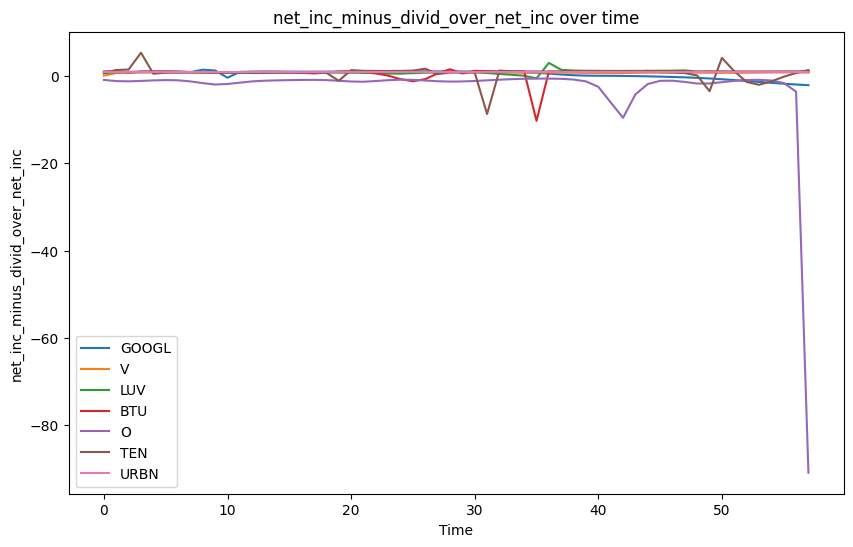

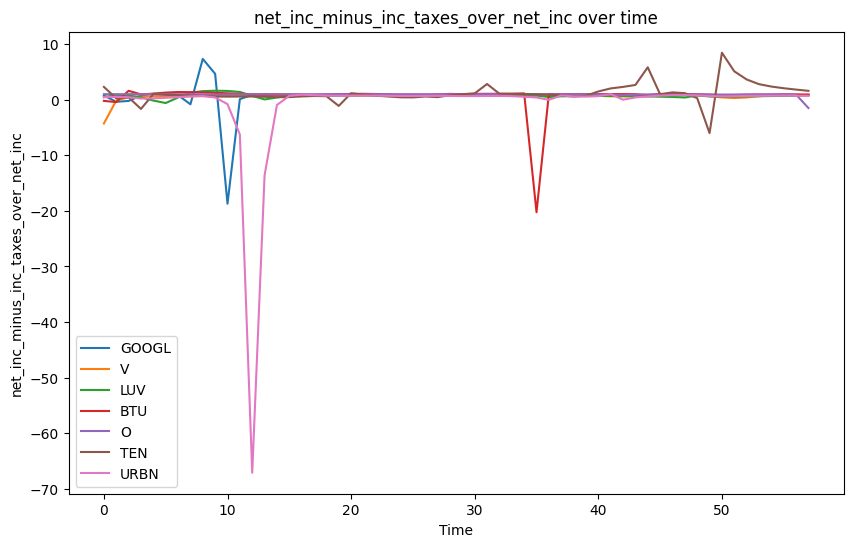

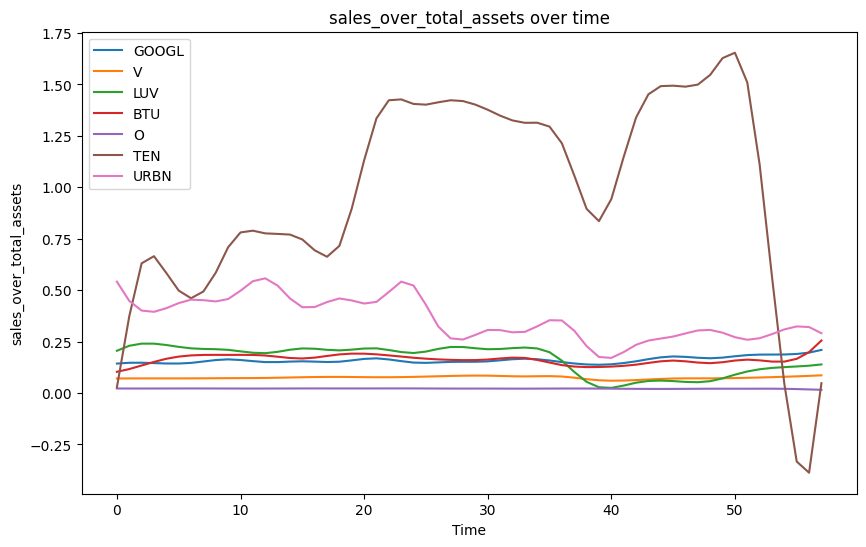

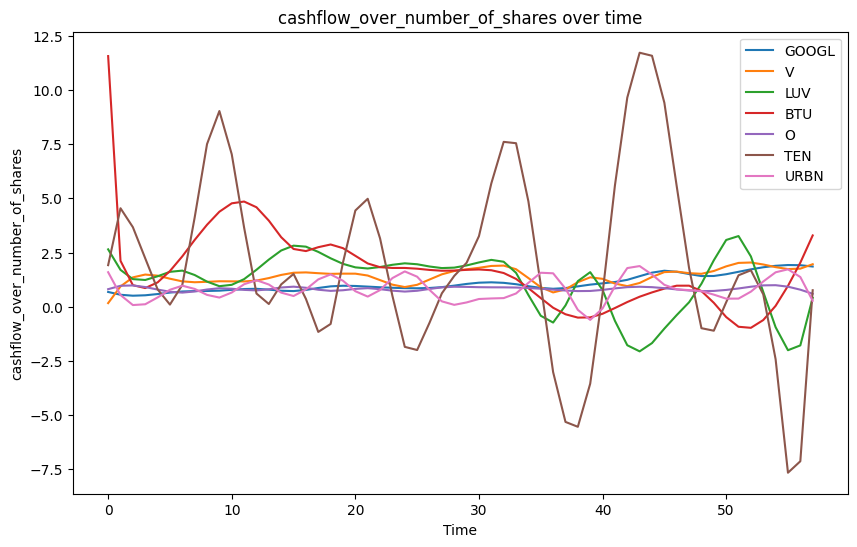

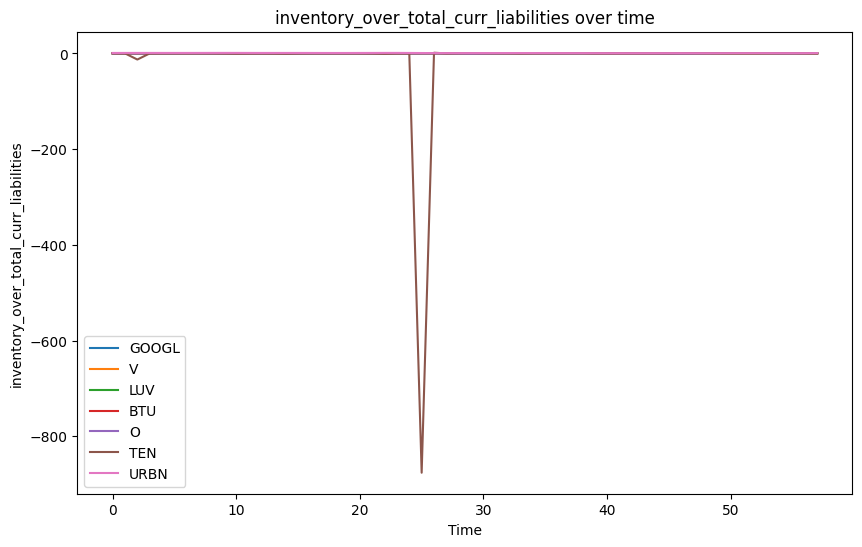

In [245]:
# plotting individual ratios over time for each stock
import matplotlib.pyplot as plt

for ratio in ratios_df.columns[4:]:
    plt.figure(figsize=(10, 6))
    for stock in stock_list:
        stock_data = ratios_df[ratios_df['Ticker'] == stock]
        plt.plot(stock_data.index%58, stock_data[ratio], label=stock)
    plt.title(f'{ratio} over time')
    plt.xlabel('Time')
    plt.ylabel(ratio)
    plt.legend()
    plt.show()

In [246]:
# we need to convert the ratios_df to a Numpy array 

import numpy as np

# removing ratios that still need to be cleaned up.
ratios_df_cleaned = ratios_df.drop(columns=['pretax_net_nonop_inc_over_sales'])

columns = ratios_df.columns[1:].to_list()

X_numpy = [
    group[columns].to_numpy()
    for _, group in ratios_df.groupby('Ticker')
]

X_numpy = np.stack(X_numpy)

In [247]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

X_scaled_ts = TimeSeriesScalerMeanVariance().fit_transform(X_numpy)

In [248]:
# now trying to do DTW like in the paper, i was unsuccessful with this last year.

from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import dtw

num_clusters = 3

model = TimeSeriesKMeans(n_clusters=num_clusters, metric="dtw", max_iter=10, random_state=42)
labels = model.fit_predict(X_scaled_ts)

print(labels)

[2 0 2 2 1 2 0]


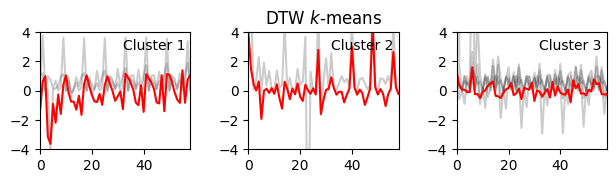

In [249]:
import matplotlib.pyplot as plt

sz = 58 # number of months

for yi in range(num_clusters):
    plt.subplot(3, 3, 7 + yi)
    for xx in X_numpy[labels == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(model.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DTW $k$-means")

plt.tight_layout()
plt.show()